In [ ]:
import pandas as pd
import numpy as np

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!ls /content/drive/MyDrive/'Colab Notebooks'/'Reviews analysis'

path = "/content/drive/MyDrive/Colab Notebooks/Reviews analysis/"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 reviews.csv   'Reviews Sentiment Analysis final.ipynb'  'Sentiment analysis webapp.ipynb'
 reviews.json  'Reviews Sentiment Analysis.ipynb'


In [ ]:
df = pd.read_csv(path +'reviews.csv')

In [ ]:
df.head()

,address,categories,city,country,latitude,longitude,name,postalCode,province,reviews.date,reviews.dateAdded,reviews.doRecommend,reviews.id,reviews.rating,reviews.text,reviews.title,reviews.userCity,reviews.username,reviews.userProvince
0,Riviera San Nicol 11/a,Hotels,Mableton,US,45.421611,12.376187,Hotel Russo Palace,30126,GA,2013-09-22T00:00:00Z,2016-10-24T00:00:25Z,NaN,NaN,4.0,Pleasant 10 min walk along the sea front to th...,Good location away from the crouds,NaN,Russ (kent),NaN
1,Riviera San Nicol 11/a,Hotels,Mableton,US,45.421611,12.376187,Hotel Russo Palace,30126,GA,2015-04-03T00:00:00Z,2016-10-24T00:00:25Z,NaN,NaN,5.0,Really lovely hotel. Stayed on the very top fl...,Great hotel with Jacuzzi bath!,NaN,A Traveler,NaN
2,Riviera San Nicol 11/a,Hotels,Mableton,US,45.421611,12.376187,Hotel Russo Palace,30126,GA,2014-05-13T00:00:00Z,2016-10-24T00:00:25Z,NaN,NaN,5.0,Ett mycket bra hotell. Det som drog ner betyge...,Lugnt l��ge,NaN,Maud,NaN
3,Riviera San Nicol 11/a,Hotels,Mableton,US,45.421611,12.376187,Hotel Russo Palace,30126,GA,2013-10-27T00:00:00Z,2016-10-24T00:00:25Z,NaN,NaN,5.0,We stayed here for four nights in October. The...,Good location on the Lido.,NaN,Julie,NaN
4,Riviera San Nicol 11/a,Hotels,Mableton,US,45.421611,12.376187,Hotel Russo Palace,30126,GA,2015-03-05T00:00:00Z,2016-10-24T00:00:25Z,NaN,NaN,5.0,We stayed here for four nights in October. The...,������ ���������������,NaN,sungchul,NaN


 ### Data Preprocessing

We only keep the columns we need.

In [ ]:
review_df = df[['reviews.title','reviews.text','reviews.rating','reviews.date']]
review_df.columns = ['title', 'text', 'rating', 'date']

In [ ]:
review_df.dtypes

,0
title,object
text,object
rating,float64
date,object


We remove comments with unreadable characters

In [ ]:
#review_df = review_df[review_df["title"].str.contains("�")==False]
review_df = review_df[review_df["text"].str.contains("�")==False]
review_df = review_df.reset_index(drop=True)

We convert dates to the right format

In [ ]:
review_df['date'] = pd.to_datetime(review_df['date'])
review_df['text'] = review_df['text'].astype(str)

In [ ]:
review_df.dtypes

,0
title,object
text,object
rating,float64
date,"datetime64[ns, UTC]"


Let's take a look at a sample :

In [ ]:
review_df.head(10)

,title,text,rating,date
0,Good location away from the crouds,Pleasant 10 min walk along the sea front to th...,4.0,2013-09-22 00:00:00+00:00
1,Great hotel with Jacuzzi bath!,Really lovely hotel. Stayed on the very top fl...,5.0,2015-04-03 00:00:00+00:00
2,Lugnt l��ge,Ett mycket bra hotell. Det som drog ner betyge...,5.0,2014-05-13 00:00:00+00:00
3,Good location on the Lido.,We stayed here for four nights in October. The...,5.0,2013-10-27 00:00:00+00:00
4,������ ���������������,We stayed here for four nights in October. The...,5.0,2015-03-05 00:00:00+00:00
5,Very nice hotel,We loved staying on the island of Lido! You ne...,5.0,2015-04-05 00:00:00+00:00
6,Lovely view out onto the lagoon. Excellent view.,Lovely view out onto the lagoon. Excellent vie...,4.0,2014-06-10 00:00:00+00:00
7,Lovely view out onto the lagoon. Excellent view.,ottimo soggiorno e ottima sistemazione nei gio...,4.0,2015-05-14 00:00:00+00:00
8,G��nstige Lage,Gnstiger Ausgangspunkt fr Venedig Besuche. Ruh...,3.0,2015-09-14 00:00:00+00:00
9,Ro og hygge,Lidoen er perfekt til et par dages ro og afsla...,4.0,2015-05-16 00:00:00+00:00


In [ ]:
len(review_df)

35684

***

We take a smaller sample to reduce processing time.

In [ ]:
nb = 300

sample = review_df['text'].head(nb).tolist()

***

### Tokenization & sentiment analysis

We call the pretrained RoBERTa transformer to get a label about sentiment (positive, negative, neutral) as well as a confidence score.

In [ ]:
from transformers import pipeline

model_path = "cardiffnlp/twitter-roberta-base-sentiment-latest"

model = pipeline(model = model_path, tokenizer = model_path, truncation=True)

review_list = sample

sentiments = model(review_list, truncation=True, max_length=512)

Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu


In [ ]:
df_sentiment = pd.DataFrame(sentiments, columns=['label', 'score'])
reviews_sentiment = pd.concat([review_df.head(nb), df_sentiment], axis=1)

***

## Word Frequency

We calculate word frequency in order to plot a word cloud. To do so we clean the comments usig different techniques such as punctuation removal, stripping, stopwords removal and lemmatization.

In [ ]:
import nltk
from nltk import word_tokenize
from nltk.probability import FreqDist
import urllib.request
from matplotlib import pyplot as plt
from wordcloud import WordCloud
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

Removing punctuation

In [ ]:
import string

def remove_punctuation(text):
    translator = str.maketrans('', '', string.punctuation)
    return text.translate(translator)

In [ ]:
reviews_sentiment['text'] = reviews_sentiment['text'].apply(remove_punctuation).str.lower()

Stripping white spaces

In [ ]:
import gensim.parsing.preprocessing as gp

reviews_sentiment['text'] = reviews_sentiment['text'].map(gp.strip_multiple_whitespaces)

Removing stopwords

In [ ]:
#Download and import list of stopwords
nltk.download("stopwords")
from nltk.corpus import stopwords

stopwords_list = stopwords.words("english")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
import spacy
load_en = spacy.load('en_core_web_sm')

Lemmatization process

In [ ]:
def lemmatize_and_remove_stopwords(text):
    words = load_en(text)
    result = [lem_word.lemma_ for lem_word in words if not lem_word.is_stop]
    return result

In [ ]:
reviews_sentiment['text'] = reviews_sentiment['text'].map(lemmatize_and_remove_stopwords)

We get the words frequency and plot the word cloud

In [ ]:
fdist_list = [FreqDist(text) for text in reviews_sentiment['text']]

wfrequence = FreqDist()
for fdist in fdist_list:
    wfrequence.update(fdist)

most_common_words = wfrequence.most_common()

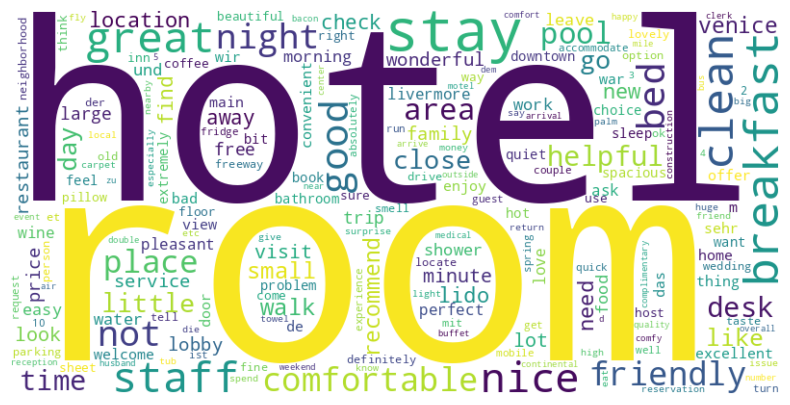

In [ ]:
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(dict(most_common_words))

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

## Most recurrent comments based on sentiment

Let's see the most recurrent words in negative reviews :

In [ ]:
reviews_negative_sentiment = reviews_sentiment[reviews_sentiment['label'] == 'negative']

fdist_list = [FreqDist(text) for text in reviews_negative_sentiment['text']]

wfrequence = FreqDist()
for fdist in fdist_list:
    wfrequence.update(fdist)

most_common_neg_words = wfrequence.most_common()

In [ ]:
reviews_positive_sentiment = reviews_sentiment[reviews_sentiment['label'] == 'positive']

fdist_list = [FreqDist(text) for text in reviews_positive_sentiment['text']]

wfrequence = FreqDist()
for fdist in fdist_list:
    wfrequence.update(fdist)

most_common_pos_words = wfrequence.most_common()

We compute the importance score for each word in negative reviews using the frequency in both positive and negative reviews.

In [ ]:
neg_word_freq = dict(most_common_neg_words)
pos_word_freq = dict(most_common_pos_words)

word_importance_ratio = {
    word: (freq + 1) / (pos_word_freq.get(word, 0) + 1)
    for word, freq in neg_word_freq.items()
  }

specific_words = {word: score for word, score in word_importance_ratio.items() if score > 0.5}

specific_words_sorted = sorted(specific_words.items(), key=lambda x: x[1], reverse=True)

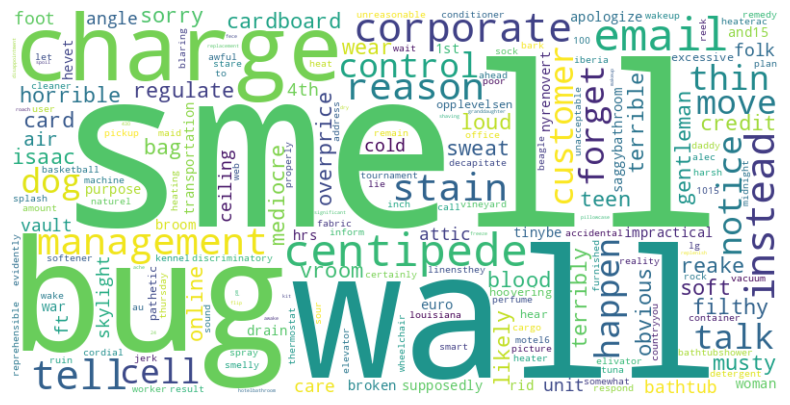

In [ ]:
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(dict(specific_words_sorted))

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

Let's now see for the positive reviews

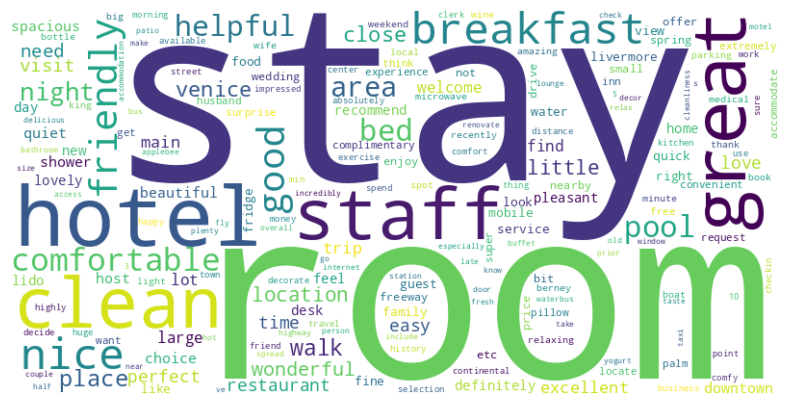

In [ ]:
neg_word_freq = dict(most_common_neg_words)
pos_word_freq = dict(most_common_pos_words)

word_importance_ratio = {
    word: (freq + 1) / (neg_word_freq.get(word, 0) + 1)
    for word, freq in pos_word_freq.items()
  }

specific_words = {word: score for word, score in word_importance_ratio.items() if score > 0.5}

specific_words_sorted = sorted(specific_words.items(), key=lambda x: x[1], reverse=True)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

***

## Visualization

We can now display some quick visualizations to have a better overview of the reviews

In [ ]:
import plotly.express as px

In [ ]:
reviews_sentiment.head()

,title,text,rating,date,label,score
0,Good location away from the crouds,"[pleasant, 10, min, walk, sea, water, bus, res...",4.0,2013-09-22 00:00:00+00:00,positive,0.793499
1,Great hotel with Jacuzzi bath!,"[lovely, hotel, stay, floor, surprise, jacuzzi...",5.0,2015-04-03 00:00:00+00:00,positive,0.985383
2,Good location on the Lido.,"[stay, night, october, hotel, staff, welcome, ...",5.0,2013-10-27 00:00:00+00:00,positive,0.939237
3,Very nice hotel,"[love, stay, island, lido, need, water, venice...",5.0,2015-04-05 00:00:00+00:00,positive,0.980950
4,Lovely view out onto the lagoon. Excellent view.,"[lovely, view, lagoon, excellent, view, staff,...",4.0,2014-06-10 00:00:00+00:00,positive,0.986510


In [ ]:
fig = px.pie(reviews_sentiment, names='label', color_discrete_sequence = px.colors.qualitative.Pastel, title='Repartition of the sentiment over the reviews')
fig.show()

In [ ]:
fig = px.pie(reviews_sentiment, names='rating', color_discrete_sequence = px.colors.qualitative.Pastel, title='Repartition of the ratings over the reviews')
fig.show()